# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

In [2]:
import pandas as pd

taxi = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv')


print(taxi.shape)
print(taxi.head())
print(taxi.info())
print(taxi.describe())

print(taxi.isna().sum())


(41202, 13)
   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94                      1       

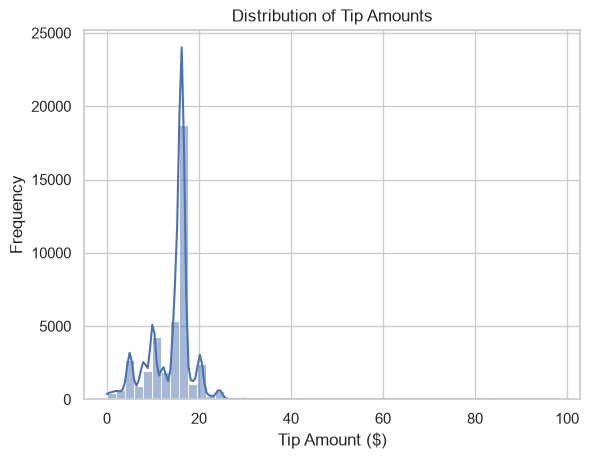

In [31]:

sns.histplot(taxi['tip_amount'], bins=50, kde=True)
plt.title("Distribution of Tip Amounts")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Frequency")
plt.show()


In [5]:

print((taxi['tip_amount'] < 0).sum(), "negative tips")
print((taxi['trip_distance'] <= 0).sum(), "zero/negative distance trips")
print((taxi['fare_amount'] < 0).sum(), "negative fares")


0 negative tips
76 zero/negative distance trips
0 negative fares


Student reasoning  

The dataset has 41,202 rows and 13 columns.There are no missing values.

When I checked for wrong values I found 0 negative tips, 76 trips with zero or negative distance, and 0 negative fares. The zero distance trips are not realistic and should be removed.

The target column is skewed to the right. Most tips are small or zero, but a few trips have very large tips. These big tips are outliers. For preprocessing

Drop the trips with zero distance.

or also keep them or separate them.

### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [8]:

taxi = taxi.dropna()


In [9]:
taxi = taxi[taxi['trip_distance'] > 0]


taxi = taxi[taxi['fare_amount'] > 0]


taxi = taxi[taxi['tip_amount'] >= 0]


In [10]:
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']


In [11]:
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']


In [12]:
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']
taxi = pd.get_dummies(taxi, columns=categorical_cols, drop_first=True)


In [14]:
from sklearn.model_selection import train_test_split


X = taxi.drop('tip_amount', axis=1)   # features
y = taxi['tip_amount']                # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [87]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount',
                'mta_tax', 'tolls_amount', 'improvement_surcharge',
                'fare_per_mile', 'total_surcharges']

scaler = StandardScaler()


X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])


X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [77]:

X = taxi.drop('tip_amount', axis=1)   
y = taxi['tip_amount']               

In [78]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42   


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


In [79]:

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)


In [80]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount',
                'mta_tax', 'tolls_amount', 'improvement_surcharge',
                'fare_per_mile', 'total_surcharges']

scaler = StandardScaler()


X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])


X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


60% of the data for training, 20% for validation, and 20% for testing.

The validation set is useful because I can test different models. The test set stays hidden until the end.

The scaler must be fit only on the training set. If I fit it on all dataI would leak information from validation and test into training. 

### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [83]:

lin_reg = LinearRegression()


tree_reg = DecisionTreeRegressor(random_state=42)
forest_reg = RandomForestRegressor(random_state=42)


In [22]:

lin_reg = LinearRegression()


tree_reg = DecisionTreeRegressor(random_state=42)
forest_reg = RandomForestRegressor(random_state=42)


In [24]:
lin_reg.fit(X_train, y_train)

tree_reg.fit(X_train, y_train)

forest_reg.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [25]:

y_train_pred_lin = lin_reg.predict(X_train)
y_val_pred_lin   = lin_reg.predict(X_val)
y_test_pred_lin  = lin_reg.predict(X_test)


y_train_pred_tree = tree_reg.predict(X_train)
y_val_pred_tree   = tree_reg.predict(X_val)
y_test_pred_tree  = tree_reg.predict(X_test)


y_train_pred_forest = forest_reg.predict(X_train)
y_val_pred_forest   = forest_reg.predict(X_val)
y_test_pred_forest  = forest_reg.predict(X_test)


In [26]:
from sklearn.metrics import mean_squared_error, r2_score


In [27]:
def report_metrics(y_true, y_pred, name="Model"):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f}, R²: {r2:.3f}")


In [28]:
report_metrics(y_train, y_train_pred_lin, "Linear Regression (Train)")
report_metrics(y_val,   y_val_pred_lin,   "Linear Regression (Val)")
report_metrics(y_test,  y_test_pred_lin,  "Linear Regression (Test)")


report_metrics(y_train, y_train_pred_tree, "Decision Tree (Train)")
report_metrics(y_val,   y_val_pred_tree,   "Decision Tree (Val)")
report_metrics(y_test,  y_test_pred_tree,  "Decision Tree (Test)")

report_metrics(y_train, y_train_pred_forest, "Random Forest (Train)")
report_metrics(y_val,   y_val_pred_forest,   "Random Forest (Val)")
report_metrics(y_test,  y_test_pred_forest,  "Random Forest (Test)")


Linear Regression (Train) -> RMSE: 4.80, R²: 0.051
Linear Regression (Val) -> RMSE: 5.04, R²: 0.049
Linear Regression (Test) -> RMSE: 5.01, R²: 0.051
Decision Tree (Train) -> RMSE: 2.38, R²: 0.767
Decision Tree (Val) -> RMSE: 6.76, R²: -0.711
Decision Tree (Test) -> RMSE: 6.76, R²: -0.727
Random Forest (Train) -> RMSE: 2.84, R²: 0.669
Random Forest (Val) -> RMSE: 5.65, R²: -0.195
Random Forest (Test) -> RMSE: 5.61, R²: -0.189


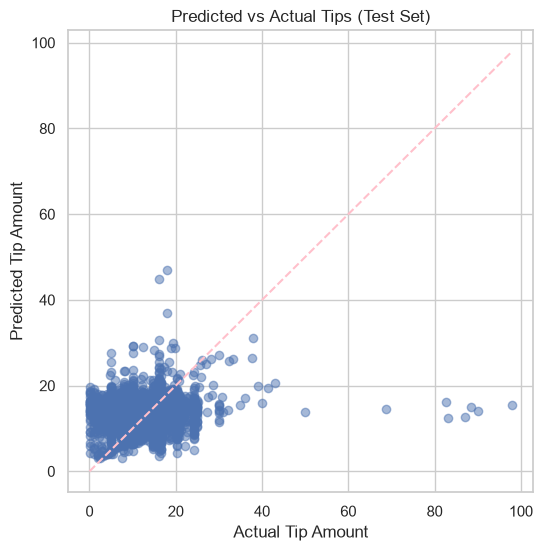

In [81]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_forest, alpha=0.5)


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='pink', linestyle='--')

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Predicted vs Actual Tips (Test Set)")
plt.show()




The Linear Regression model did best on the validation set. 

Train RMSE = 4.80, Val RMSE = 5.04, Test RMSE = 5.01 results are weak, and underfitting.
To reduce overfitting, I would make the trees smaller 

---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

In [33]:
obesity = pd.read_csv(OBESITY_URL)


print(obesity.shape)
print(obesity.head())


(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportat

In [34]:
print("Shape:", obesity.shape)


print(obesity.head())


print(obesity.info())


print(obesity.describe())


print(obesity.isna().sum())


Shape: (2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Tran

In [35]:

print(obesity['NObeyesdad'].value_counts())


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


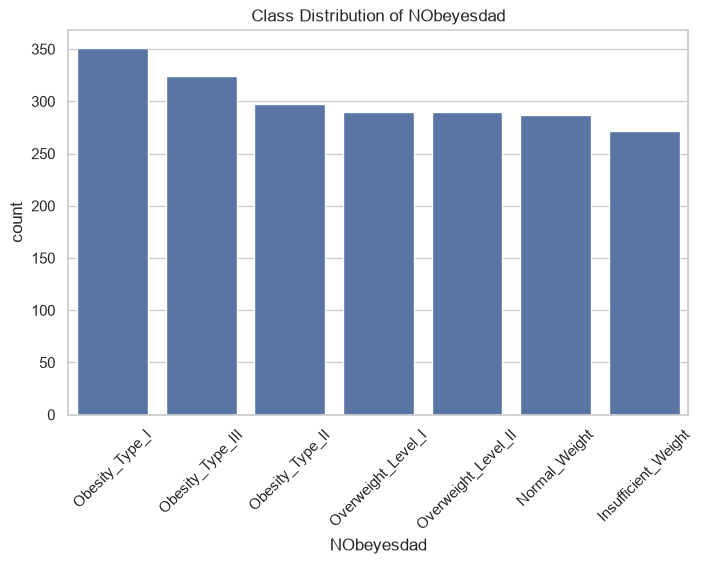

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x='NObeyesdad', data=obesity, order=obesity['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Distribution of NObeyesdad")
plt.show()


  
The dataset has 2111 rows and 17 features.

Numeric columns: Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE, CALC, BMI.

Categorical columns: Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, MTRANS.

The target NObeyesdad has 7 classes. Counts show some classes that are larger, while others are smaller. This means the data is not good balanced.


### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [85]:
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']


for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})


In [38]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ['CAEC', 'CALC']
encoder = OrdinalEncoder()

obesity[ordinal_cols] = encoder.fit_transform(obesity[ordinal_cols])


In [39]:
obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True)


In [86]:
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

print(obesity[['Weight', 'Height', 'BMI']].head())


   Weight  Height        BMI
0    64.0    1.62  24.386526
1    56.0    1.52  24.238227
2    77.0    1.80  23.765432
3    87.0    1.80  26.851852
4    89.8    1.78  28.342381


In [41]:
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()


obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])


print(obesity['NObeyesdad'].unique())


[1 5 6 2 0 3 4]


In [50]:
numeric_cols = ['passenger_count','trip_distance','fare_amount',
                'mta_tax','tolls_amount','improvement_surcharge',
                'fare_per_mile','total_surcharges']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])


X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [52]:
numeric_cols = ['Age','Height','Weight','CH2O','FAF','TUE','BMI']


In [88]:
print(X_train.columns.tolist())


['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'fare_per_mile', 'total_surcharges', 'RatecodeID_2', 'RatecodeID_4', 'RatecodeID_5', 'store_and_fwd_flag_1']


I turned yes/no columns into 0 and 1.

I made a new feature BMI = Weight / Height2. It is very related to obesity level, so it can make prediction easier. It is fair if the goal is accuracy

I used StandardScaler for numeric features so they are on the same scale. 


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [53]:

y = obesity['NObeyesdad']


X = obesity.drop(columns=['NObeyesdad'])


print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2111, 20)
y shape: (2111,)


In [54]:
from sklearn.model_selection import train_test_split


In [ ]:

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,          
    stratify=y,             
    random_state=RANDOM_STATE
)


In [56]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,         
    stratify=y_temp,       
    random_state=RANDOM_STATE
)


In [57]:
print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("Val class distribution:\n", y_val.value_counts(normalize=True))
print("Test class distribution:\n", y_test.value_counts(normalize=True))


Train class distribution:
 NObeyesdad
2    0.166667
4    0.153239
3    0.140600
6    0.137441
5    0.137441
1    0.135861
0    0.128752
Name: proportion, dtype: float64
Val class distribution:
 NObeyesdad
2    0.165877
4    0.154028
3    0.139810
6    0.137441
5    0.137441
1    0.135071
0    0.130332
Name: proportion, dtype: float64
Test class distribution:
 NObeyesdad
2    0.165485
4    0.153664
3    0.141844
1    0.137116
6    0.137116
5    0.137116
0    0.127660
Name: proportion, dtype: float64


In [58]:

numeric_cols = [col for col in ['Age','Height','Weight','CH2O','FAF','TUE','BMI'] 
                if col in X_train.columns]
print("Numeric columns:", numeric_cols)


Numeric columns: ['Age', 'Height', 'Weight', 'CH2O', 'FAF', 'TUE', 'BMI']


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])


X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


60% for training, 20% for validation, and 20% for testing.

Using stratify=y is important because the target has 7 obesity classes that are not perfectly balanced. Stratification makes sure each split keeps the same class proportions as the full dataset.

Without stratifying, some classes could end up missing


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)


rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_train)


knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [61]:
print("LogReg Validation Accuracy:", log_reg.score(X_val, y_val))
print("RandomForest Validation Accuracy:", rf_clf.score(X_val, y_val))
print("KNN Validation Accuracy:", knn_clf.score(X_val, y_val))


LogReg Validation Accuracy: 0.8838862559241706
RandomForest Validation Accuracy: 0.9928909952606635
KNN Validation Accuracy: 0.8744075829383886


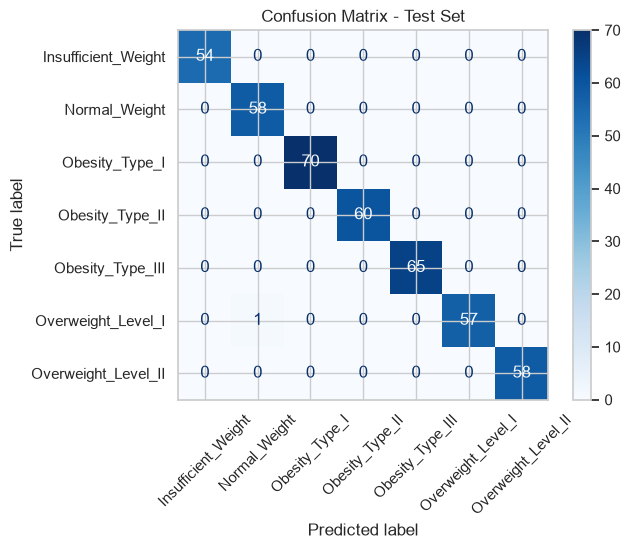

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_test_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()


In [62]:

y_train_pred = rf_clf.predict(X_train)
y_val_pred   = rf_clf.predict(X_val)
y_test_pred  = rf_clf.predict(X_test)


print("Train predictions sample:", y_train_pred[:10])
print("Validation predictions sample:", y_val_pred[:10])
print("Test predictions sample:", y_test_pred[:10])


Train predictions sample: [0 6 2 0 6 3 6 6 5 3]
Validation predictions sample: [3 0 1 4 2 1 1 3 6 5]
Test predictions sample: [0 1 6 4 3 2 3 1 2 5]


In [63]:
y_val_proba = rf_clf.predict_proba(X_val)
print("Validation probabilities shape:", y_val_proba.shape)


Validation probabilities shape: (422, 7)


I chose the Random Forest classifier because it gave the highest validation accuracy 

Train, validation, and test accuracy were all high for Random Forest, showing the model is well‑fitted. 

From the confusion matrix, the hardest obesity levels to tell apart are the neighboring categories

---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


In [65]:

X_cluster = obesity.drop(columns=['NObeyesdad'])


In [66]:
numeric_cols = [col for col in ['Age','Height','Weight','CH2O','FAF','TUE','BMI'] 
                if col in X_cluster.columns]
print("Numeric columns:", numeric_cols)


Numeric columns: ['Age', 'Height', 'Weight', 'CH2O', 'FAF', 'TUE', 'BMI']


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])


X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [68]:

X_scaled = scaler.fit_transform(X_cluster[numeric_cols])


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
K_range = range(2, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))


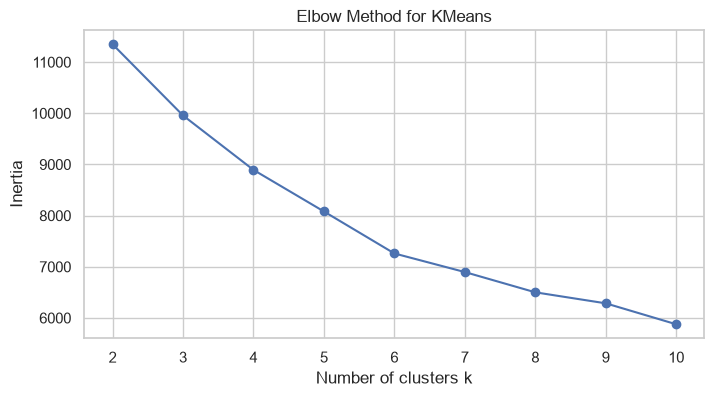

In [70]:
plt.figure(figsize=(8,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()


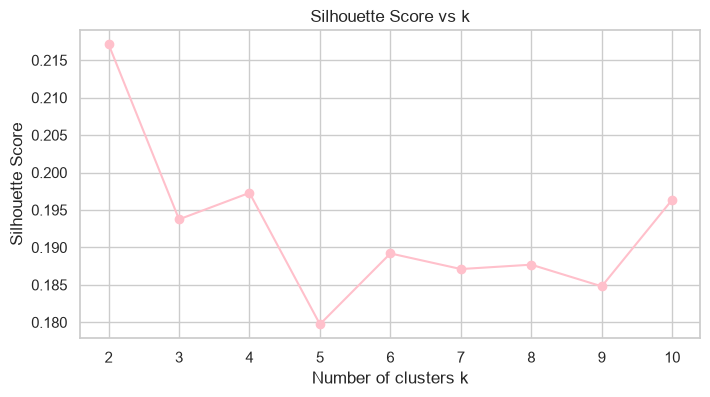

In [89]:
plt.figure(figsize=(8,4))
plt.plot(K_range, sil_scores, marker='o', color='pink')
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()


In [72]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=7, random_state=RANDOM_STATE)

kmeans.fit(X_scaled)


cluster_labels = kmeans.labels_

print("Cluster labels sample:", cluster_labels[:20])


Cluster labels sample: [0 2 5 5 4 2 2 6 6 0 5 5 5 1 0 6 3 4 1 2]


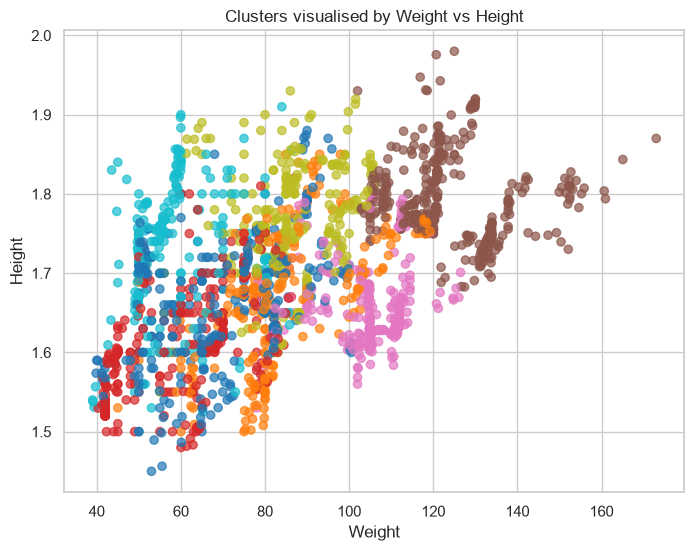

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_cluster['Weight'], X_cluster['Height'], 
            c=cluster_labels, cmap='tab10', alpha=0.7)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Clusters visualised by Weight vs Height")
plt.show()


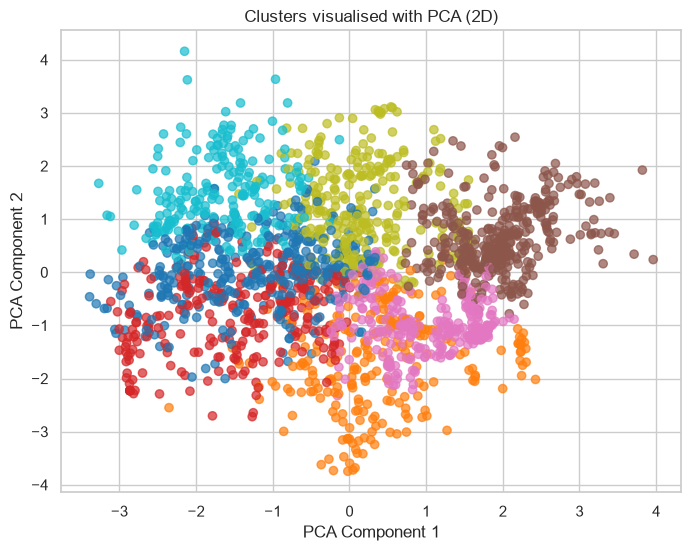

In [74]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], 
            c=cluster_labels, cmap='tab10', alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clusters visualised with PCA (2D)")
plt.show()


In [75]:
import pandas as pd

ct = pd.crosstab(cluster_labels, obesity['NObeyesdad'])
print(ct)


NObeyesdad    0   1   2    3    4   5   6
row_0                                    
0            51  83  49    3    0  77  84
1             2  12  73   53    0  41  71
2            81  89  25    0    0  87  26
3             0   0  70  186  136   0   1
4             0   0  50   55  188   0  15
5             6  37  81    0    0  80  75
6           132  66   3    0    0   5  18


I chose k by looking at the Elbow and Silhouette plots. The Elbow showed the drop slowing around k = 3–4, silhouette score was highest at k = 2. Together this make us say thst small k values give the clearest separation.

In the crosstab, some clusters matched real obesity levels and agree with the true labels but break down where classes are close in BMI or lifestyle.

In a real public‑health setting, clusters can be useful when labels are expensive to collect. 

Supervised vs unsupervised: The classifier used the labels to learn which features match each obesity group. K‑Means only made groups by similarity, so it could not match the real labels exactly.

Regression vs classification: In regression, I checked numbers with RMSE and R to 2 to see how close predictions were to the real values. In classification I checked accuracy and confusion matrices to see if the predicted class was correct.

Overfitting: The biggest gap was with the Decision Tree in the taxi tips task. It was very good on training but very poor on validation and test. The best fix was to make the tree smaller.


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
